# Report

Questo notebook verrà utilizzato per mostrare passo passo l'analisi fatta a partire dai dati grezzi fino alla creazione dei modelli di forecasting e la valutazione di essi.

## Approccio utilizzato

> 1. Descriptive analysis
> 2. Preprocessing
> 3. Modelli statistici baseline
> 4. Modelli ML non neurali
> 5. Modelli neurali
> 6. Confronto prestazionale
> 7. Inferential statistics sui confronti
> 8. Prescriptive analytics 

NB_Gli step 3-4-5 comprenderanno anche la parte di parameter fitting.


## 1. Analisi descrittiva (step by step)

In questa sezione riportiamo, nello stesso ordine del codice Python, metriche e grafici già generati in `Results/` per la serie **Produzione lorda totale**.

### 1.0 Caricamento dei risultati


In [115]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

# Risoluzione robusta della root progetto
project_root = Path.cwd()
if not (project_root / "Results").exists() and (project_root.parent / "Results").exists():
    project_root = project_root.parent

metrics_dir = project_root / "Results" / "metrics"
plots_dir = project_root / "Results" / "plots" / "descriptive"

# Caricamento metriche generate dallo script principale
series_df = pd.read_csv(metrics_dir / "tavola_1_14_series_clean_v1.csv")
freq_df = pd.read_csv(metrics_dir / "tavola_1_14_frequency_distribution_v1.csv")
central_df = pd.read_csv(metrics_dir / "tavola_1_14_central_tendency_v1.csv")
dispersion_df = pd.read_csv(metrics_dir / "tavola_1_14_dispersion_measures_v1.csv")
outliers_df = pd.read_csv(metrics_dir / "tavola_1_14_outliers_iqr_v1.csv")
outlier_summary_df = pd.read_csv(metrics_dir / "tavola_1_14_outliers_summary_v1.csv")

print(f"Project root: {project_root}")
print(f"Rows in cleaned series: {len(series_df)}")

Project root: c:\Users\giann\Documents\GitHub\FinalProject
Rows in cleaned series: 131


### 1.1 Serie base

Visualizzazione della serie annuale (1883 in avanti) per capirne l'andamento con un primo approccio visivo

,year,produzione_lorda_totale
0,1883,1.0
1,1884,2.0
2,1885,3.0
3,1886,3.0
4,1887,4.0
5,1888,5.0
6,1889,6.0
7,1890,8.0
8,1891,15.0
9,1892,22.0


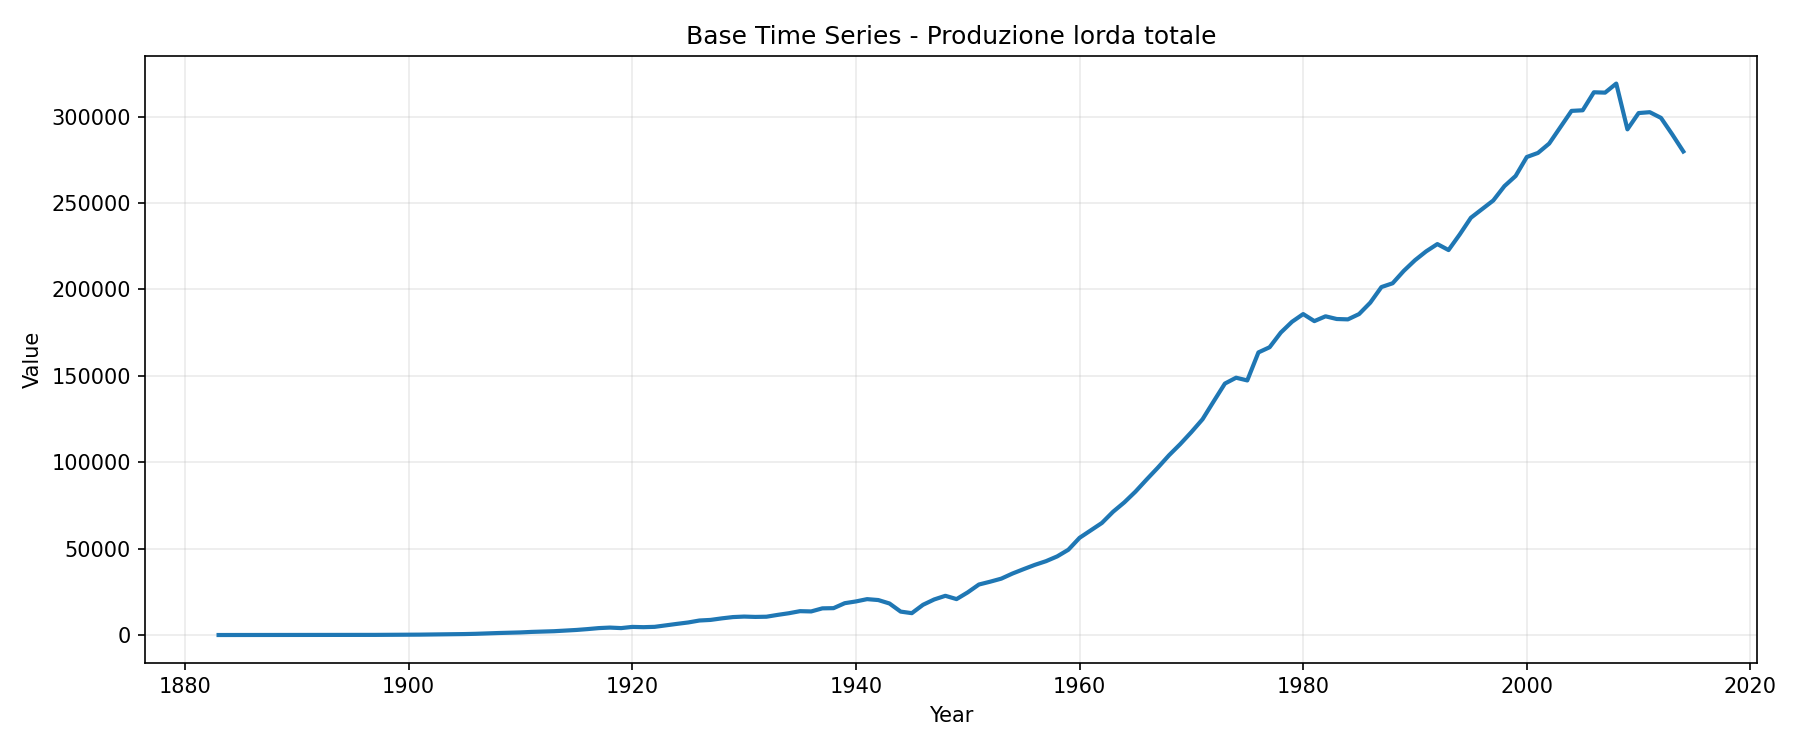

In [116]:
display(series_df.head(10))
display(Image(filename=str(plots_dir / "tavola_1_14_series_base_v1.png")))

### 1.2 Frequency distribution (empirica, relativa, bar chart)

La tabella seguente contiene le classi con frequenza assoluta e relativa.

,class_interval,absolute_frequency,relative_frequency
0,"(-318.13, 35459.778]",71,0.541985
1,"(35459.778, 70918.556]",9,0.068702
2,"(70918.556, 106377.333]",6,0.045802
3,"(106377.333, 141836.111]",4,0.030534
4,"(141836.111, 177294.889]",6,0.045802
5,"(177294.889, 212753.667]",11,0.083969
6,"(212753.667, 248212.444]",6,0.045802
7,"(248212.444, 283671.222]",6,0.045802
8,"(283671.222, 319130.0]",12,0.091603


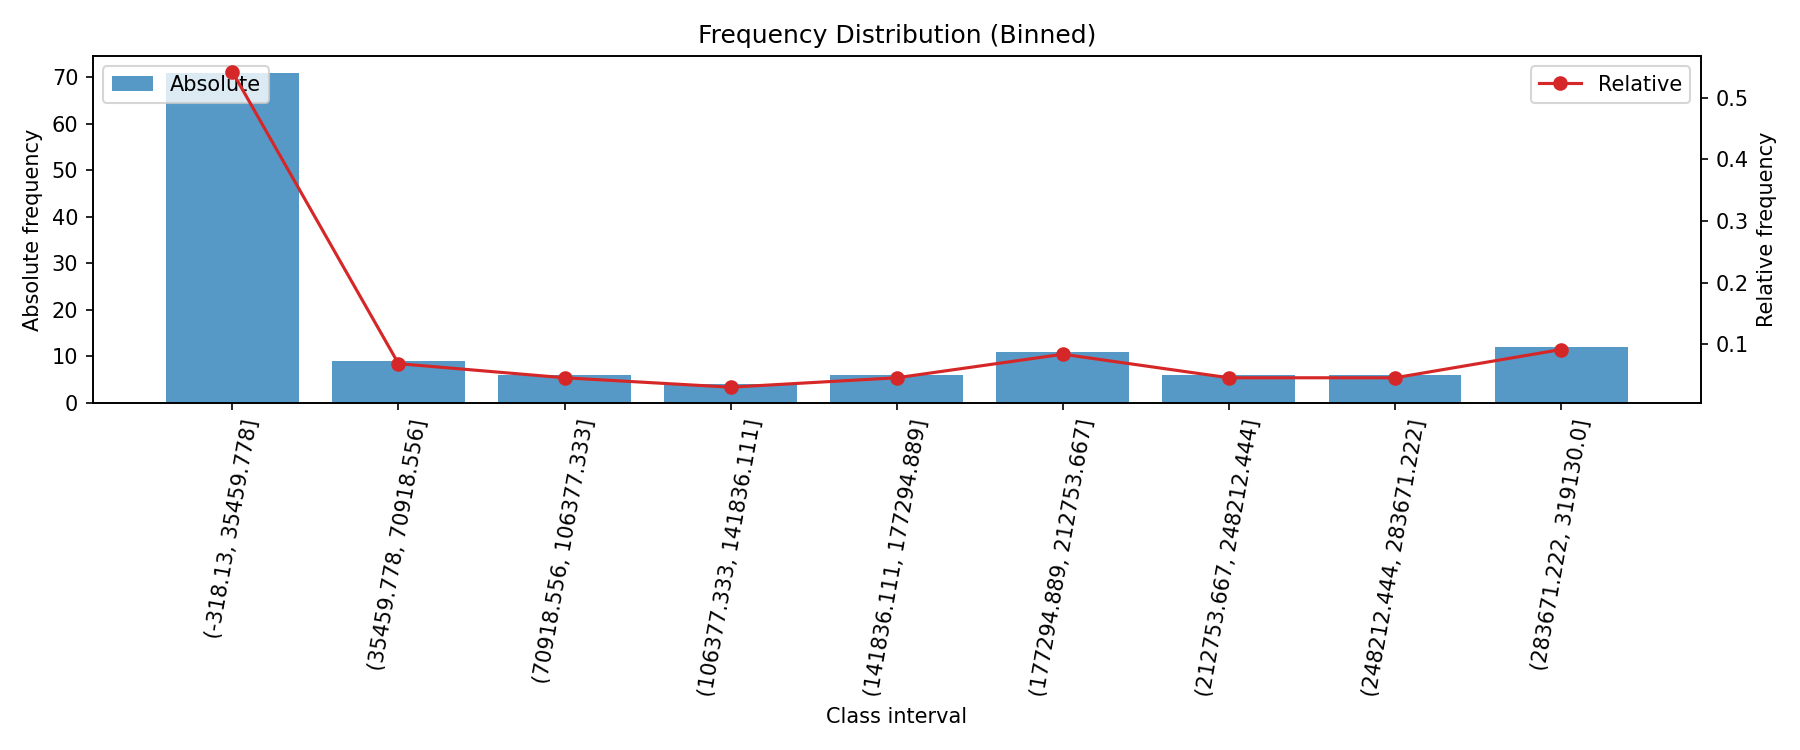

In [117]:
display(freq_df)
display(Image(filename=str(plots_dir / "tavola_1_14_frequency_distribution_v1.png")))

### 1.3 Central tendency e dispersion measures

Qui riportiamo media, mediana, moda, e poi range, varianza, deviazione standard, coefficiente di variazione e IQR.

In [118]:
display(central_df)
display(dispersion_df)

,mean,median,mode
0,88682.969466,20782.0,3.0


,range,variance,std_dev,coefficient_of_variation,iqr
0,319129.0,1.147613e+10,107126.719733,1.207974,178987.5


### 1.4 Outliers globali e studio della distribuzione

Outlier globali identificati con regola IQR sui livelli della serie. Per confronto coerente usiamo il boxplot sui livelli; in aggiunta mostriamo densita empirica vs fit normale/uniforme, distribuzione discreta e Q-Q plot.

,lower_fence,upper_fence,num_outliers,outlier_ratio
0,-265306.25,450643.75,0,0.0


,year,value


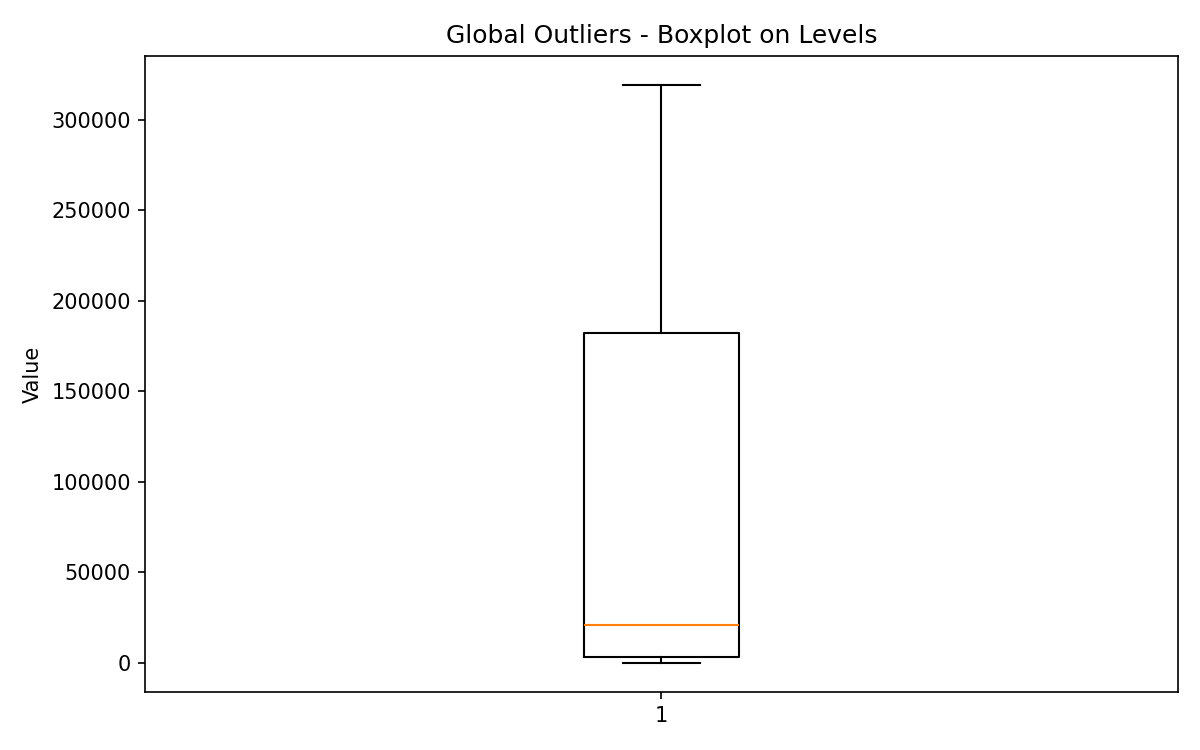

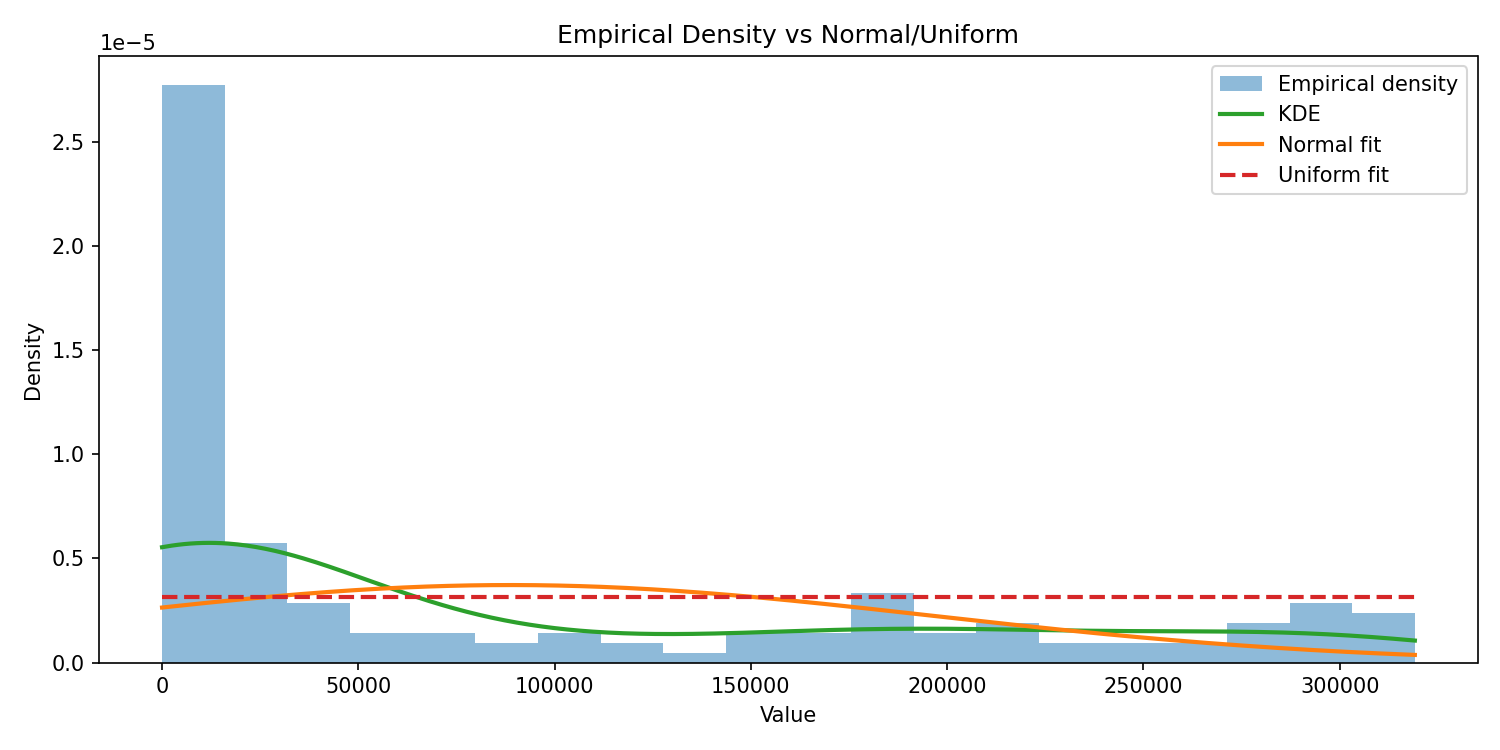

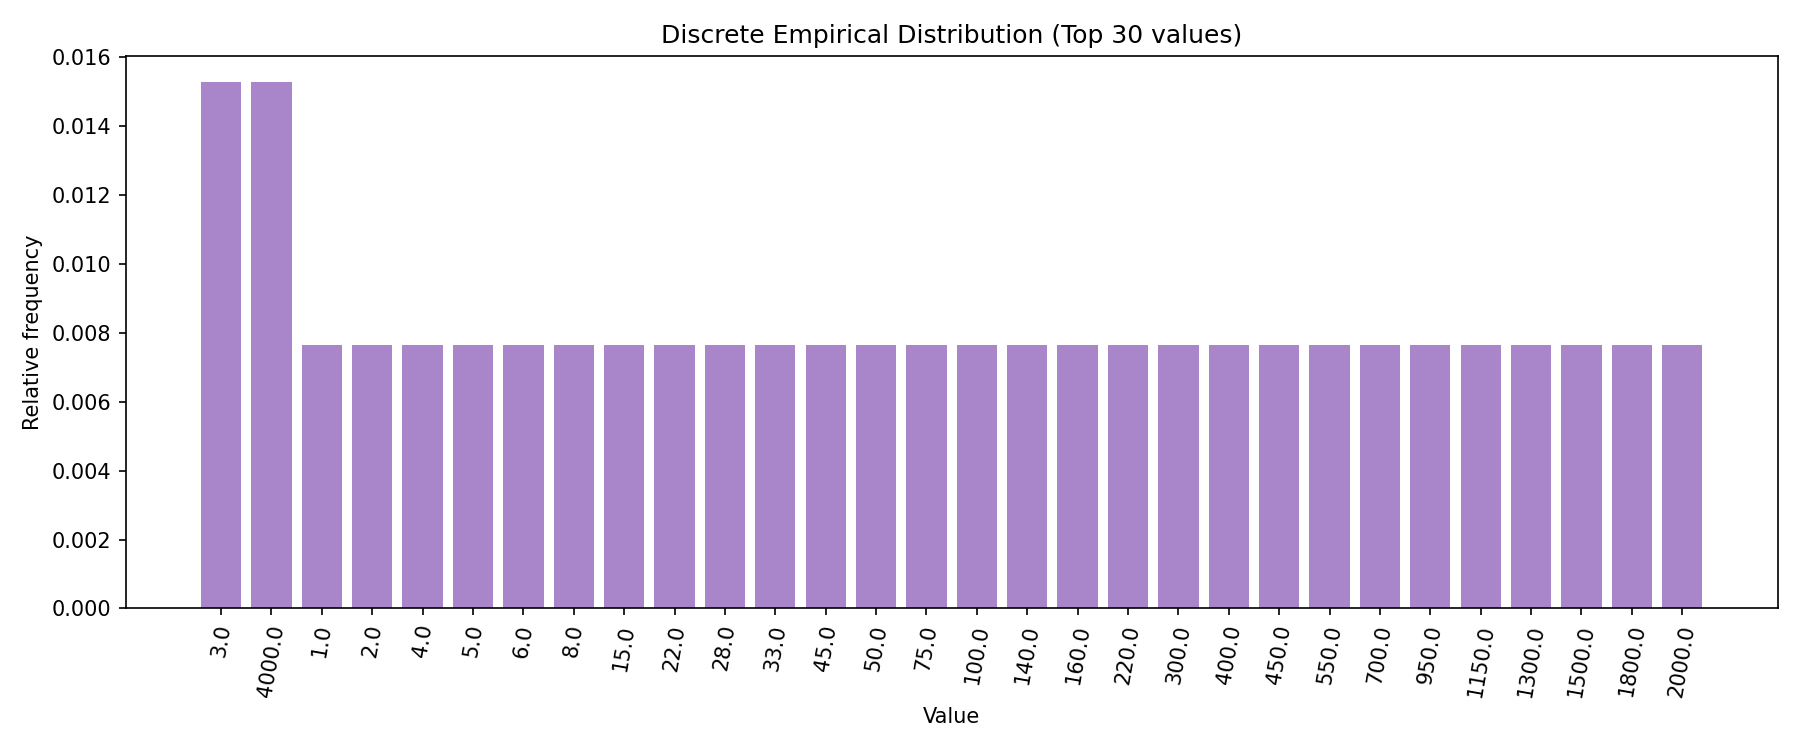

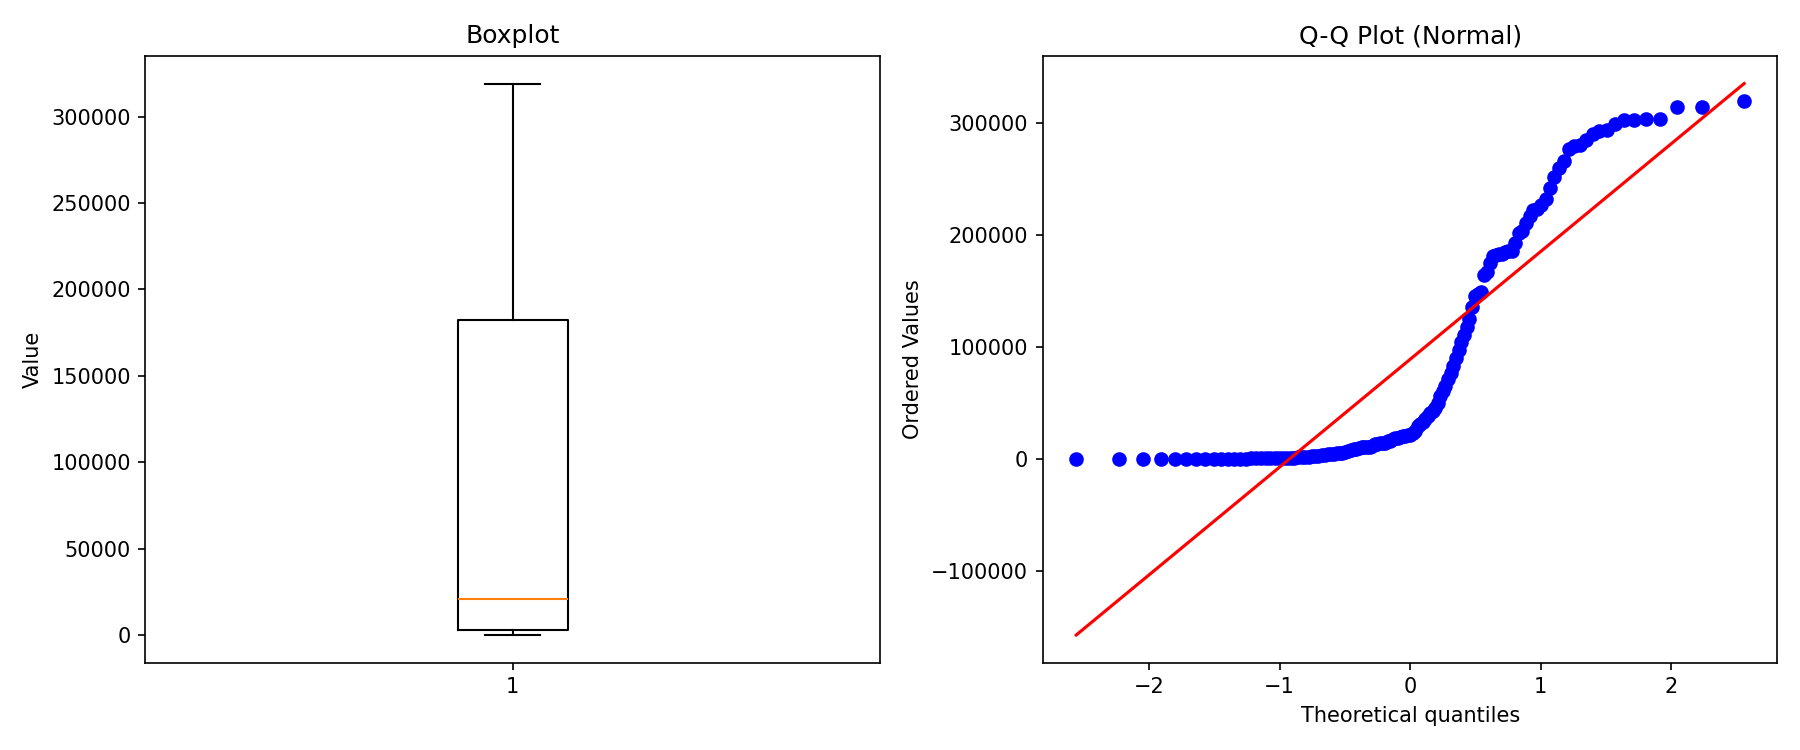

In [119]:
display(outlier_summary_df)
display(outliers_df.head(20))

# Stessa tipologia grafica usata anche per gli outlier locali (sezione 1.5)
display(Image(filename=str(plots_dir / "tavola_1_14_global_outliers_boxplot_v1.png")))

display(Image(filename=str(plots_dir / "tavola_1_14_density_comparison_v1.png")))
display(Image(filename=str(plots_dir / "tavola_1_14_discrete_distribution_v1.png")))
display(Image(filename=str(plots_dir / "tavola_1_14_outliers_qqplot_v1.png")))

### 1.5 Validazione numerica di trend crescente e anomalie locali

Per evitare che il trend globale nasconda variazioni anomale locali, analizziamo:

- trend lineare e correlazione con il tempo;
- variazioni anno su anno (YoY);
- outlier locali su YoY con baseline mobile (rolling median).

Per confronto omogeneo con la sezione 1.4, usiamo anche qui un boxplot (sulle variazioni YoY).

,n_observations,start_year,end_year,slope_per_year,slope_p_value,r_squared,spearman_rho,spearman_p_value,positive_yoy_share,negative_yoy_share,zero_yoy_share,intercept,slope_std_err
0,131,1883,2014,2548.968845,1.266610e-50,0.824752,0.997843,1.825742e-154,0.846154,0.146154,0.007692,-4.877059e+06,103.451136


,window,threshold,n_yoy_points,num_local_outliers,local_outlier_ratio,yoy_mean,yoy_std,yoy_q05,yoy_q95
0,11,3.5,130,2,0.015385,2152.523077,4700.087435,-2705.95,9580.6


,year,yoy_change,local_median_change,residual_vs_local,rolling_mad,local_score,is_local_outlier
0,1960,6890.0,4294.0,2596.0,256.0,6.839852,True
1,2009,-26488.0,351.0,-26839.0,5055.0,-3.581188,True


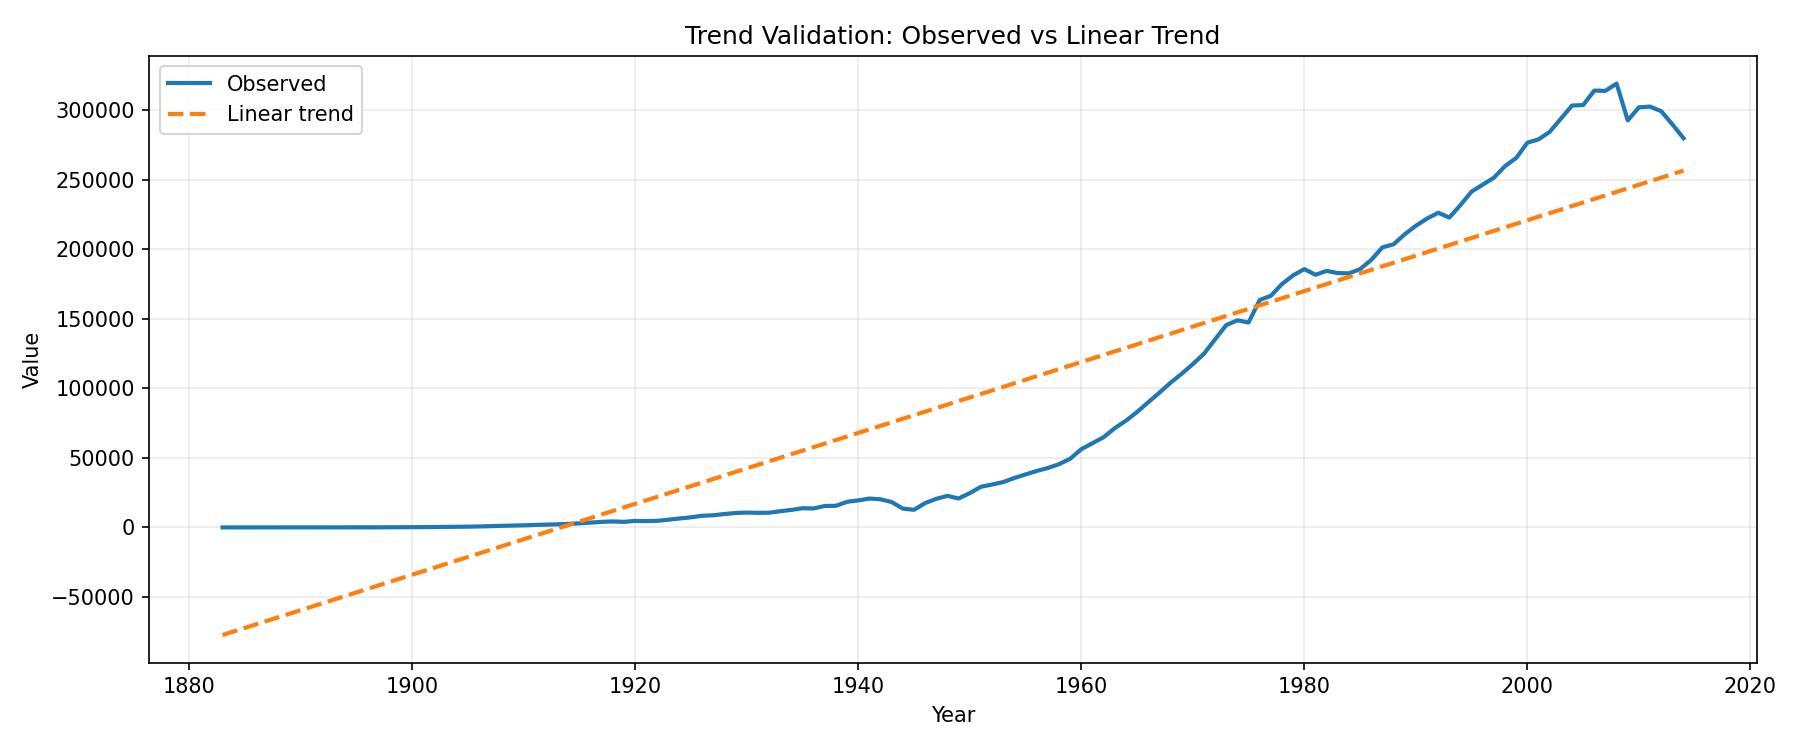

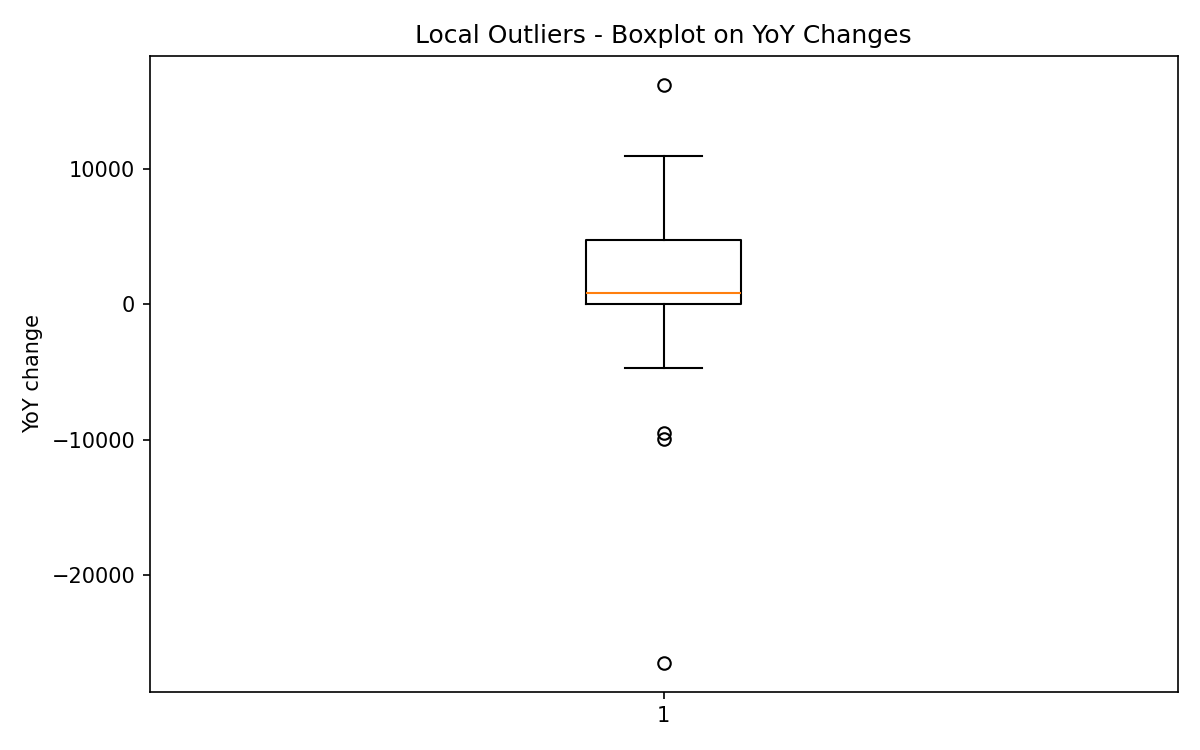

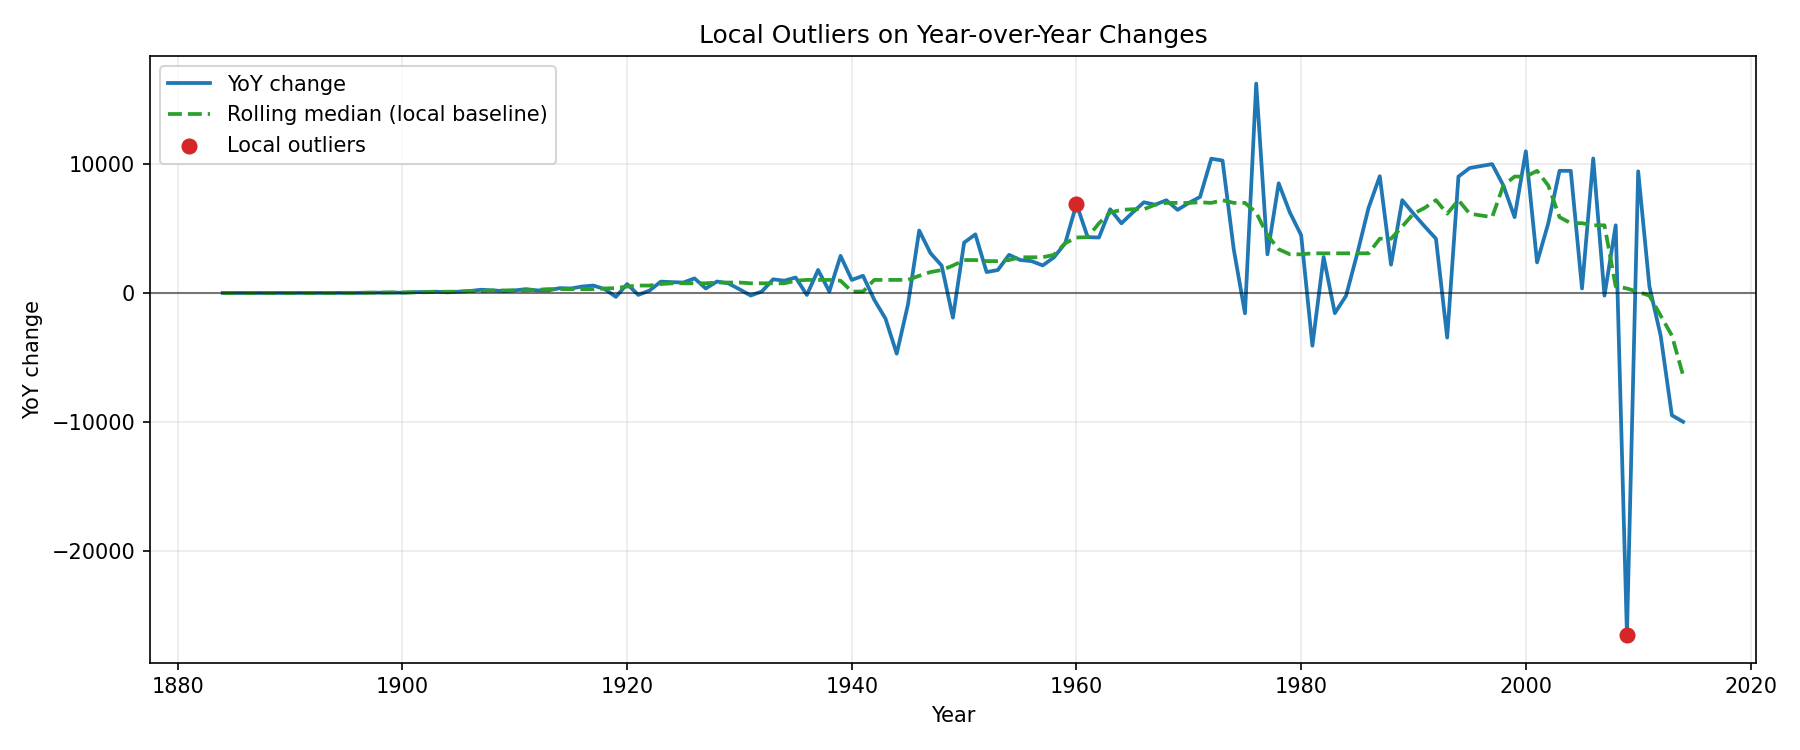

In [120]:
trend_summary_df = pd.read_csv(metrics_dir / "tavola_1_14_trend_summary_v1.csv")
local_outliers_summary_df = pd.read_csv(metrics_dir / "tavola_1_14_local_outliers_summary_v1.csv")
local_outliers_df = pd.read_csv(metrics_dir / "tavola_1_14_local_outliers_yoy_v1.csv")

display(trend_summary_df)
display(local_outliers_summary_df)
display(local_outliers_df)

display(Image(filename=str(plots_dir / "tavola_1_14_trend_validation_v1.png")))
display(Image(filename=str(plots_dir / "tavola_1_14_local_outliers_boxplot_v1.png")))
display(Image(filename=str(plots_dir / "tavola_1_14_local_outliers_yoy_v1.png")))

### 1.6 Confronto tra analisi globale e locale

Il confronto tra le due analisi mostra che non ci sono outlier globali sui livelli (IQR), ma emergono poche anomalie locali quando si osservano le variazioni anno-su-anno rispetto a una baseline mobile. Questo risultato e coerente con una serie a trend crescente: i valori elevati negli anni recenti non sono necessariamente anomali in senso assoluto, mentre alcuni salti o crolli puntuali rappresentano shock locali. Di conseguenza, nella fase di preprocessing e preferibile trattare queste osservazioni come eventi specifici della dinamica temporale, evitando rimozioni automatiche basate solo su soglie globali.

## 2. Preprocessing

In questa sezione applichiamo il preprocessing tenendo conto delle conclusioni della fase descrittiva: trend forte, assenza di outlier globali e presenza di pochi shock locali.

Checklist operativa adottata:

1. split temporale train/validation/test senza leakage;
2. trasformazioni candidate (nessuna, diff1, log1p+diff1, log1p+diff2);
3. test di stazionarieta su train (ADF + KPSS, Shapiro opzionale);
4. rilevazione outlier locali su variazioni YoY (rolling baseline);
5. scelta configurazione finale per lo Step 3.

Criterio decisionale per stazionarieta (train):
- ADF: p-value < 0.05
- KPSS: p-value >= 0.05

### 2.0 Setup e artefatti

Carichiamo una sola volta metriche e grafici generati dallo script, cosi le sottosezioni successive restano pulite e focalizzate.

In [121]:
preproc_metrics_dir = project_root / "Results" / "metrics"
preproc_plots_dir = project_root / "Results" / "plots" / "preprocessing"

preproc_split_df = pd.read_csv(preproc_metrics_dir / "tavola_1_14_preproc_split_summary_v1.csv")
preproc_tests_df = pd.read_csv(preproc_metrics_dir / "tavola_1_14_preproc_tests_v1.csv")
preproc_candidates_df = pd.read_csv(preproc_metrics_dir / "tavola_1_14_preproc_candidate_tests_v1.csv")
preproc_local_outliers_df = pd.read_csv(preproc_metrics_dir / "tavola_1_14_preproc_local_outliers_v1.csv")

preproc_candidates_ranked = preproc_candidates_df.sort_values("adf_pvalue_train")
best_stationary = preproc_candidates_ranked[
    (preproc_candidates_ranked["adf_stationary_train"] == True)
    & (preproc_candidates_ranked["kpss_stationary_train"] == True)
]

best_cfg_row = (best_stationary.head(1) if len(best_stationary) > 0 else preproc_candidates_ranked.head(1)).iloc[0]

### 2.1 Split temporale

Lo split viene fatto in ordine cronologico, senza shuffle, per evitare leakage tra passato e futuro.

,split,start,end,n
0,train,1884,1974,91
1,val,1975,1993,19
2,test,1994,2014,20


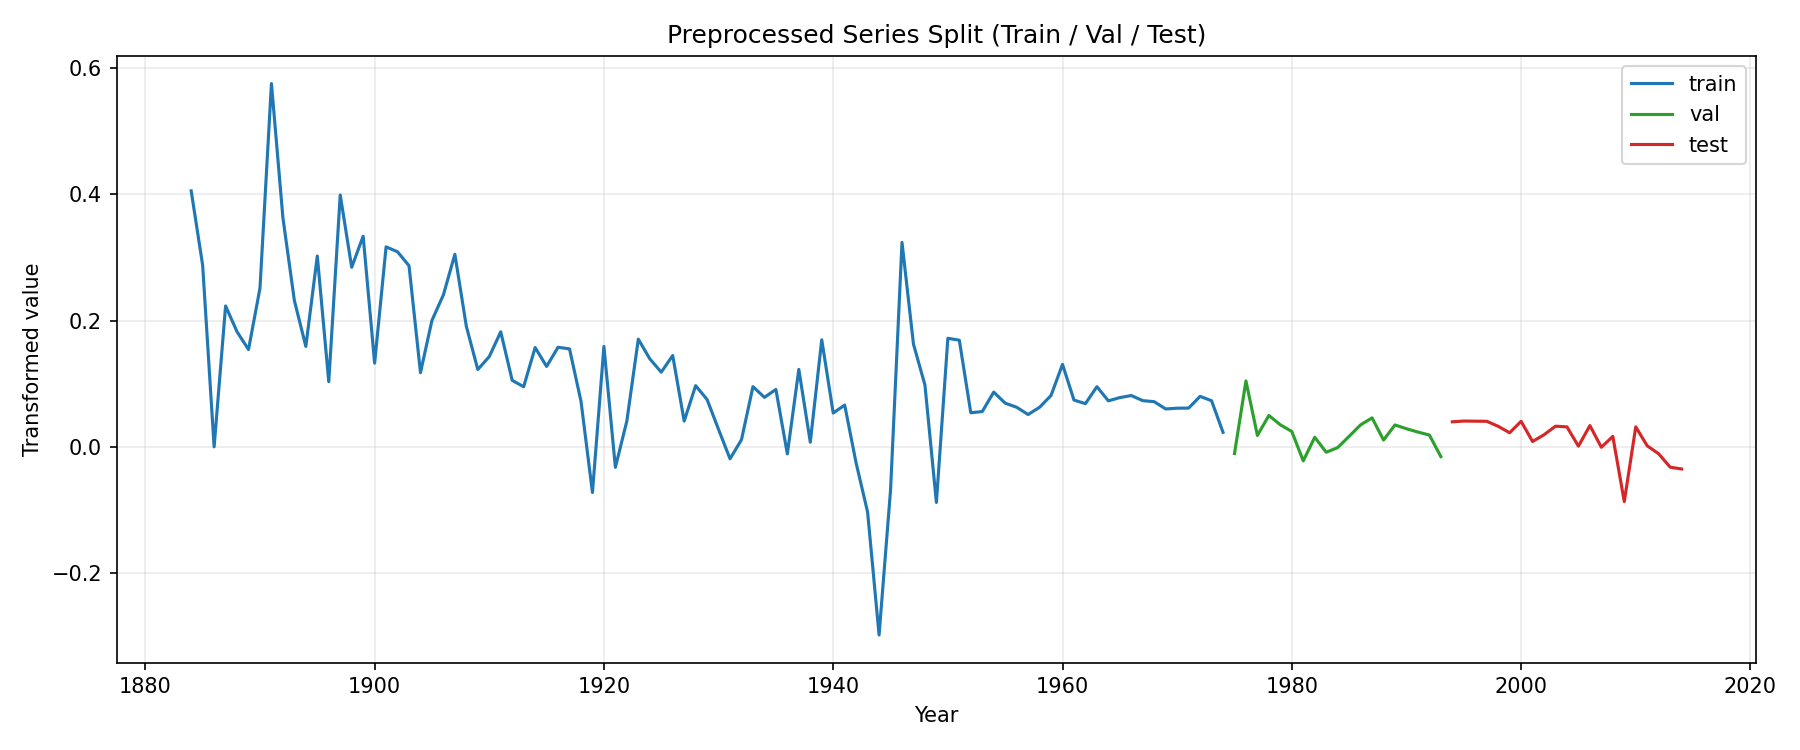

In [122]:
display(preproc_split_df)
display(Image(filename=str(preproc_plots_dir / "tavola_1_14_preproc_split_view_v1.png")))

### 2.2 Trasformazioni candidate

Confrontiamo le configurazioni candidate usando i test sul train, poi selezioniamo quella che soddisfa meglio il criterio ADF+KPSS.

,use_log1p,power_exponent,diff_order,scale_method,adf_pvalue_train,kpss_pvalue_train,adf_stationary_train,kpss_stationary_train
3,True,NaN,2,none,6.055981e-18,0.10,True,True
2,True,NaN,1,none,5.285964e-01,0.01,False,False
1,False,NaN,1,none,9.692541e-01,0.01,False,False
0,False,NaN,0,none,1.000000e+00,0.01,False,False


,use_log1p,power_exponent,diff_order,scale_method,adf_pvalue_train,kpss_pvalue_train,adf_stationary_train,kpss_stationary_train
3,True,NaN,2,none,6.055981e-18,0.1,True,True


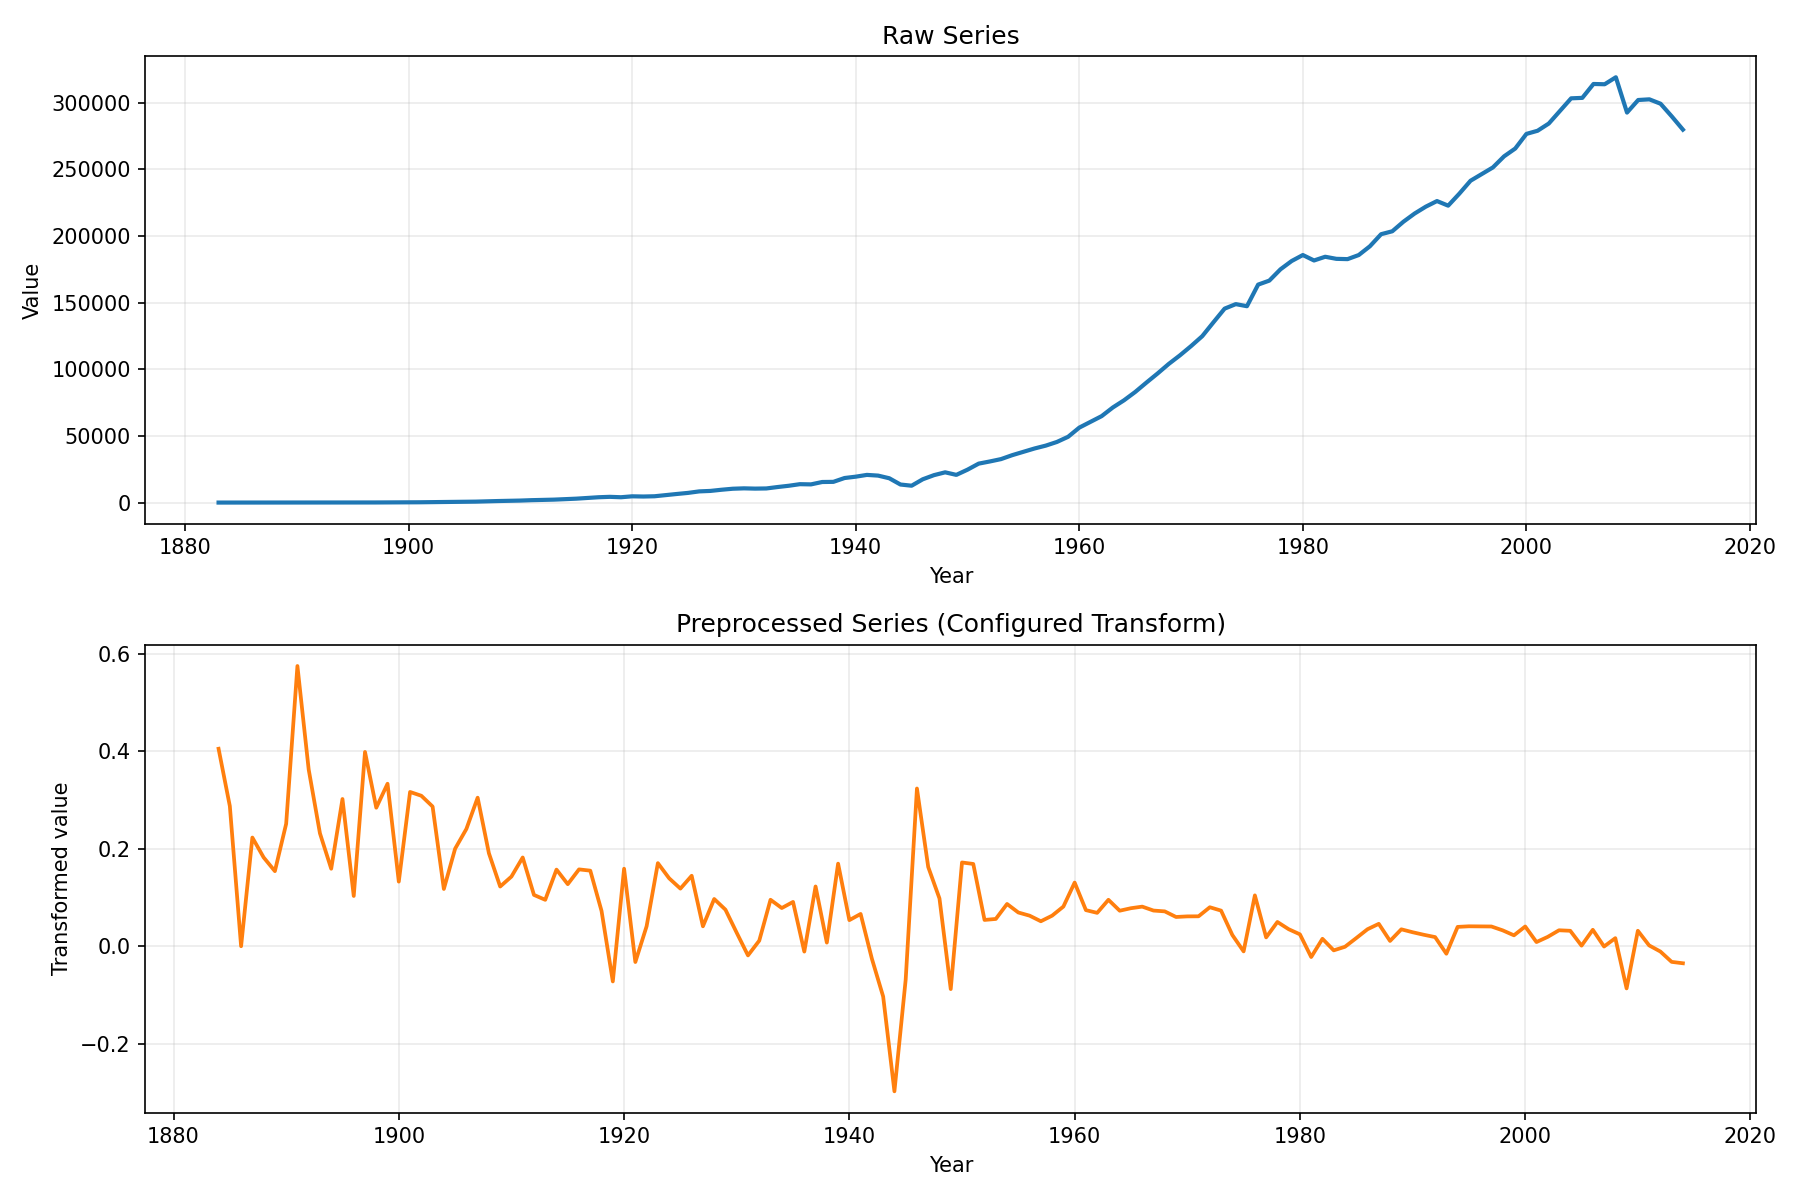

In [123]:
display(preproc_candidates_ranked)
display(best_stationary.head(1) if len(best_stationary) > 0 else preproc_candidates_ranked.head(1))
display(Image(filename=str(preproc_plots_dir / "tavola_1_14_preproc_raw_vs_transformed_v1.png")))

### 2.3 Test di stazionarieta

Valutiamo ADF e KPSS su train/validation/test e annotiamo la decisione principale sul train set.

,split,n,adf_stat,adf_pvalue,adf_stationary_at_05,kpss_stat,kpss_pvalue,kpss_stationary_at_05,shapiro_stat,shapiro_pvalue,shapiro_normal_at_05,kpss_note
0,train,91,-1.509924,0.528596,False,1.257905,0.01,False,0.945443,0.000821,False,The test statistic is outside of the range of ...
1,val,19,-1.978027,0.296290,False,0.156836,0.10,True,0.913523,0.085934,True,The test statistic is outside of the range of ...
2,test,20,1.681642,0.998083,False,0.800338,0.01,False,0.822782,0.001928,False,The test statistic is outside of the range of ...


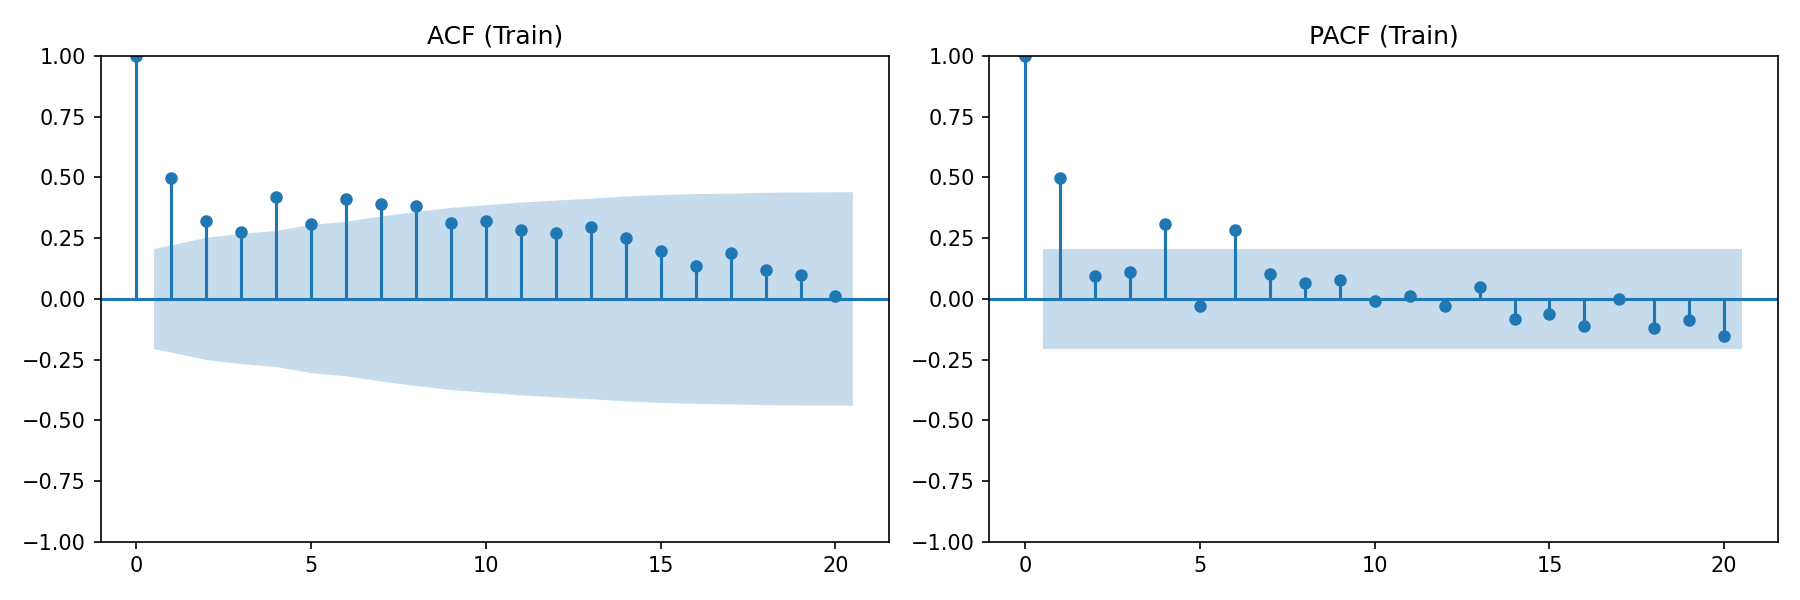

Train - criterio stazionarieta:
ADF p-value = 0.528596 -> NO
KPSS p-value = 0.01 -> NO


In [124]:
display(preproc_tests_df)
display(Image(filename=str(preproc_plots_dir / "tavola_1_14_preproc_acf_pacf_v1.png")))

train_tests = preproc_tests_df.loc[preproc_tests_df["split"] == "train"].iloc[0]
print("Train - criterio stazionarieta:")
print(f"ADF p-value = {train_tests['adf_pvalue']:.6g} -> {'OK' if bool(train_tests['adf_stationary_at_05']) else 'NO'}")
print(f"KPSS p-value = {train_tests['kpss_pvalue']:.6g} -> {'OK' if bool(train_tests['kpss_stationary_at_05']) else 'NO'}")

### 2.4 Rilevazione outlier locali su variazioni YoY

Gli outlier locali vengono stimati sulle variazioni anno-su-anno rispetto a una baseline mobile, in coerenza con quanto visto nello Step 1.

,year,yoy_change,rolling_median,rolling_mad,local_score,is_local_outlier
76,1960,6890.0,4294.0,256.0,6.839852,True
124,2009,-26488.0,351.0,5055.0,-3.581188,True


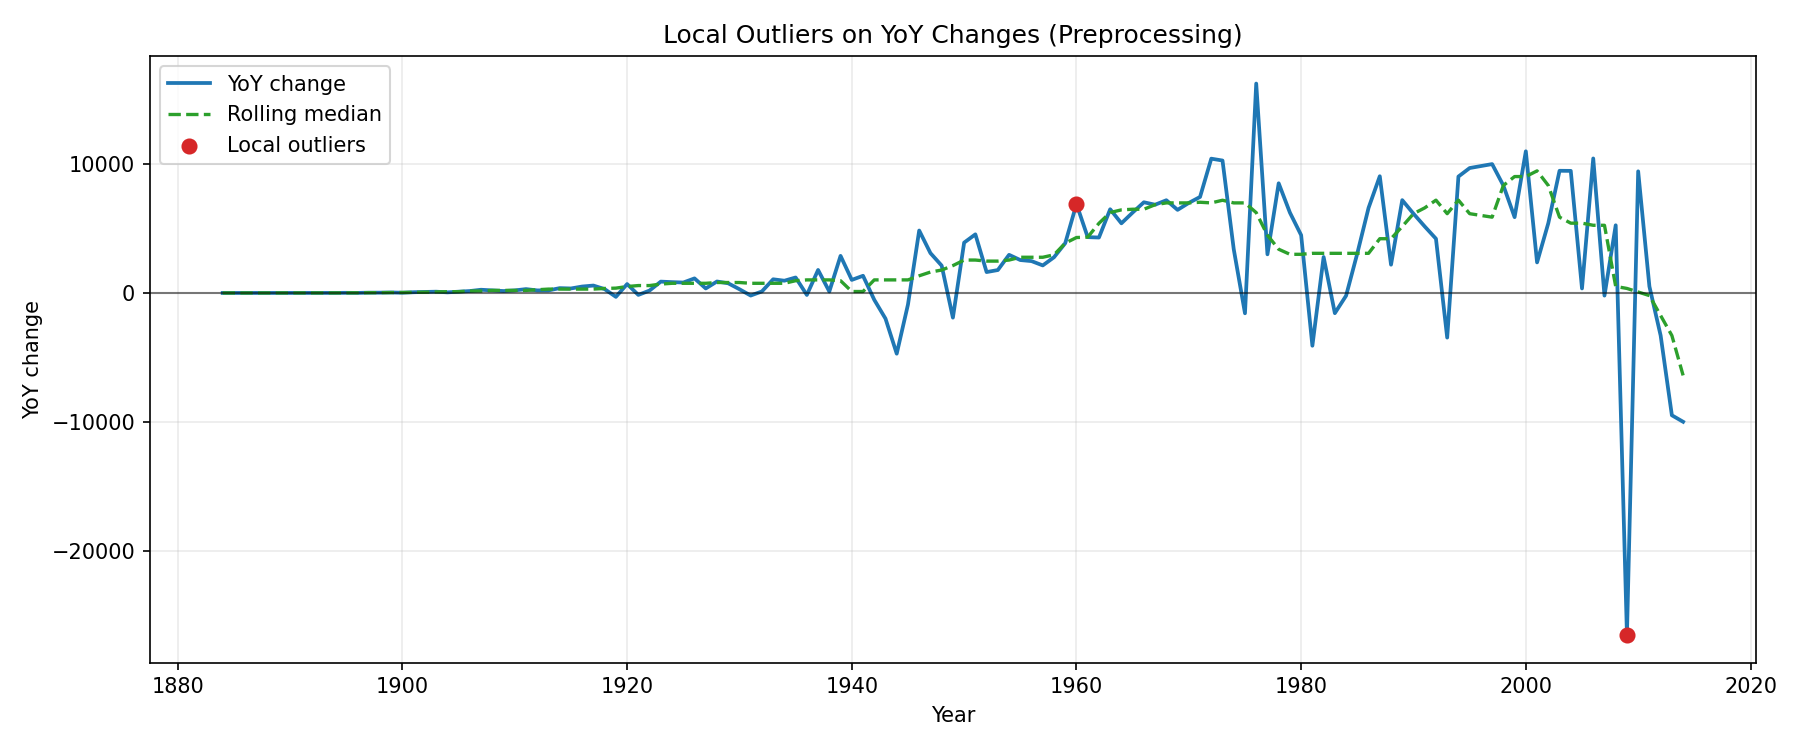

In [125]:
display(preproc_local_outliers_df[preproc_local_outliers_df["is_local_outlier"] == True].head(20))
display(Image(filename=str(preproc_plots_dir / "tavola_1_14_preproc_local_outliers_v1.png")))

### 2.5 Preprocessing Conclusion: Statistical

Configurazione consigliata per il modello statistico: **log1p + differencing di ordine 1** (senza scaling).
Motivazione: nella selezione delle candidate, questa è la configurazione che soddisfa il criterio di stazionarietà sul train (ADF significativo e KPSS non significativo), minimizzando l'accumulo di errore nell'inversione.

### 2.6 Preprocessing Conclusion: Non-Neural ML

Per i modelli ML non neurali manteniamo la stessa pipeline base (coerenza sperimentale), ma consideriamo come adattamento a valle il feature engineering su lag e, se necessario, scaling.
Configurazione iniziale: **log1p + diff1** come baseline condivisa; eventuale confronto secondario con livelli scalati nel solo ramo ML.

### 2.7 Preprocessing Conclusion: Neural Network

Per i modelli neurali usiamo la stessa base di preprocessing per mantenere comparabilita con gli altri modelli, applicando poi nel blocco Neural il windowing e l'eventuale scaling specifico (fit solo su train).
Configurazione baseline di input: **log1p + diff1**, con possibilita di esperimento aggiuntivo su livelli scalati come analisi di sensibilita.

### 2.8 Final Decision Table

Tabella sintetica delle decisioni di preprocessing per famiglia modello.

In [133]:
final_preproc_decisions = pd.DataFrame(
    [
        {
            "model_family": "Statistical",
            "base_transform": "log1p + diff1",
            "input_scale": "no scaling",
            "notes": "Target stazionario su train secondo ADF+KPSS.",
        },
        {
            "model_family": "Non-Neural ML",
            "base_transform": "log1p + diff1",
            "input_scale": "optional (fit on train only)",
            "notes": "Stessa baseline per comparabilita; feature lag nel ramo ML.",
        },
        {
            "model_family": "Neural Network",
            "base_transform": "log1p + diff1",
            "input_scale": "optional (fit on train only)",
            "notes": "Windowing sequenziale e tuning specifico nel ramo neural.",
        },
    ]
)

final_preproc_decisions

,model_family,base_transform,input_scale,notes
0,Statistical,log1p + diff1,no scaling,Target stazionario su train secondo ADF+KPSS.
1,Non-Neural ML,log1p + diff1,optional (fit on train only),Stessa baseline per comparabilita; feature lag...
2,Neural Network,log1p + diff1,optional (fit on train only),Windowing sequenziale e tuning specifico nel r...


# 3 Statistical Model




### 3.0 Setup e artefatti

> Carichiamo i risultati prodotti da main.py per Step 3 (SARIMA + Holt-Winters).

In [127]:
stat_metrics_dir = project_root / "Results" / "metrics"
stat_plots_dir = project_root / "Results" / "plots" / "forecasting"
stat_artifacts_dir = project_root / "Results" / "artifacts"

sarima_grid_df = pd.read_csv(stat_metrics_dir / "tavola_1_14_stat_sarima_grid_v1.csv")
hw_grid_df = pd.read_csv(stat_metrics_dir / "tavola_1_14_stat_hw_grid_v1.csv")
stat_summary_df = pd.read_csv(stat_metrics_dir / "tavola_1_14_stat_summary_v1.csv")
stat_residual_diag_df = pd.read_csv(stat_metrics_dir / "tavola_1_14_stat_residual_diagnostics_v1.csv")
stat_forecasts_df = pd.read_csv(stat_metrics_dir / "tavola_1_14_stat_forecasts_v1.csv")
stat_winner_params = pd.read_json(stat_artifacts_dir / "tavola_1_14_stat_winner_params_v1.json", typ="series")

print(f"SARIMA candidate rows: {len(sarima_grid_df)}")
print(f"HW candidate rows: {len(hw_grid_df)}")
display(stat_summary_df)

SARIMA candidate rows: 18
HW candidate rows: 3


,model,best_params,rmse_val,mae_val,mape_val,mbe_val,abs_mbe_val,rmse_val_orig,mae_val_orig,mape_val_orig,mbe_val_orig,abs_mbe_val_orig,rmse_test,mae_test,mape_test,mbe_test,abs_mbe_test,aic,aicc
0,sarima,"{'order': (1, 0, 2), 'seasonal_order': (0, 0, ...",0.027190,0.019989,194.961412,0.001036,0.001036,6301.982527,5327.089365,2.909305,-1038.596485,1038.596485,0.031036,0.023201,253.583146,0.002133,0.002133,-207.226901,-206.845948
1,holt_winters,"{'trend': 'add', 'seasonal': None, 'damped_tre...",0.028503,0.022886,228.765446,0.003442,0.003442,18451.696192,15528.268920,8.003022,15472.642364,15472.642364,0.040781,0.037892,543.279144,-0.032414,0.032414,-517.843322,-517.027788


### 3.1 Configurazione modello

- **Pipeline unica**: stessi split train/validation/test del preprocessing.
- **SARIMA**: ricerca su griglia ridotta con $d=2$ e ordine stagionale coerente con la frequenza.
- **HW benchmark**: configurazioni additive/moltiplicative (o non stagionali se la frequenza non supporta stagione).

In [128]:
display(preproc_split_df)
print("Best candidate SARIMA (top 10 by validation RMSE):")
display(sarima_grid_df.head(10))

print("Best candidate Holt-Winters (top 10 by validation RMSE):")
display(hw_grid_df.head(10))

,split,start,end,n
0,train,1884,1974,91
1,val,1975,1993,19
2,test,1994,2014,20


Best candidate SARIMA (top 10 by validation RMSE):


,order,seasonal_order,rmse_val,mae_val,mape_val,mbe_val,abs_mbe_val,rmse_val_orig,mae_val_orig,mape_val_orig,mbe_val_orig,abs_mbe_val_orig,aic,aicc,k_params,rank_rmse_val,rank_abs_mbe_val
0,"(1, 0, 2)","(0, 0, 0, 0)",0.027190,0.019989,194.961412,0.001036,0.001036,6301.982527,5327.089365,2.909305,-1038.596485,1038.596485,-152.987804,-152.522688,4,6301.982527,1038.596485
1,"(2, 0, 1)","(0, 0, 0, 0)",0.027383,0.020153,189.982596,0.000151,0.000151,6470.759512,5464.077765,2.960207,-2735.096159,2735.096159,-155.212244,-154.747127,4,6470.759512,2735.096159
2,"(0, 1, 0)","(0, 0, 0, 0)",0.027952,0.020133,199.762073,0.001803,0.001803,6933.849602,5414.245026,2.974150,-2281.997919,2281.997919,-121.889651,-121.844707,1,6933.849602,2281.997919
3,"(2, 0, 0)","(0, 0, 0, 0)",0.030385,0.024455,124.367200,-0.013057,0.013057,28166.863448,23818.989798,11.787896,-23189.639592,23189.639592,-136.089733,-135.813871,3,28166.863448,23189.639592
4,"(1, 1, 0)","(0, 0, 0, 0)",0.031592,0.024122,293.768507,0.013982,0.013982,32873.449700,25997.195697,12.753870,24722.170624,24722.170624,-129.341038,-129.204674,2,32873.449700,24722.170624
5,"(1, 0, 0)","(0, 0, 0, 0)",0.032554,0.026285,107.910391,-0.017860,0.017860,39151.698662,34378.477835,17.121324,-33945.741804,33945.741804,-135.868902,-135.732538,2,39151.698662,33945.741804
6,"(0, 0, 1)","(0, 0, 0, 0)",0.035052,0.027342,100.376275,-0.021166,0.021166,47173.804117,42361.397713,21.204909,-42184.026546,42184.026546,-99.310457,-99.174093,2,47173.804117,42184.026546
7,"(0, 0, 0)","(0, 0, 0, 0)",0.035039,0.027302,100.000000,-0.021206,0.021206,47274.902015,42462.526316,21.256689,-42297.052632,42297.052632,-61.108234,-61.063290,1,47274.902015,42297.052632
8,"(0, 0, 2)","(0, 0, 0, 0)",0.036265,0.027647,99.785251,-0.021680,0.021680,48474.126239,43717.789918,21.909528,-43571.490369,43571.490369,-122.458735,-122.182873,3,48474.126239,43571.490369
9,"(2, 1, 0)","(0, 0, 0, 0)",0.035280,0.029216,363.121352,0.022136,0.022136,57743.609908,45416.241364,22.183813,45379.886160,45379.886160,-137.741875,-137.466013,3,57743.609908,45379.886160


Best candidate Holt-Winters (top 10 by validation RMSE):


,trend,seasonal,damped_trend,rmse_val,mae_val,mape_val,mbe_val,abs_mbe_val,rmse_val_orig,mae_val_orig,mape_val_orig,mbe_val_orig,abs_mbe_val_orig,aic,aicc,rank_rmse_val,rank_abs_mbe_val
0,add,NaN,False,0.028503,0.022886,228.765446,0.003442,0.003442,18451.696192,15528.268920,8.003022,15472.642364,15472.642364,-411.410068,-410.410068,18451.696192,15472.642364
1,add,NaN,True,0.032902,0.026257,327.039899,0.018027,0.018027,46474.904784,36966.930368,18.123922,36822.082351,36822.082351,-413.895840,-412.546443,46474.904784,36822.082351
2,NaN,NaN,False,0.051251,0.047229,554.904599,0.042996,0.042996,138327.109080,109584.712279,53.471748,109584.712279,109584.712279,-413.237913,-412.772797,138327.109080,109584.712279


### 3.2 Accuracy e Parameter Fitting

Valutiamo ogni combinazione su **validation** con RMSE/MAE/MAPE.
AIC/AICc viene usato come tie-breaker tra combinazioni con accuracy simile.

In [129]:
sort_col = "rmse_val_orig" if "rmse_val_orig" in stat_summary_df.columns else "rmse_val"

metric_cols = [
    "model",
    "rmse_val",
    "mae_val",
    "mape_val",
    "mbe_val",
    "abs_mbe_val",
    "rmse_val_orig",
    "mae_val_orig",
    "mape_val_orig",
    "mbe_val_orig",
    "abs_mbe_val_orig",
    "rmse_test",
    "mae_test",
    "mape_test",
    "mbe_test",
    "abs_mbe_test",
    "aic",
    "aicc",
]
metric_cols = [c for c in metric_cols if c in stat_summary_df.columns]

display(stat_summary_df[metric_cols].sort_values(sort_col))

best_sarima_row = sarima_grid_df.iloc[0]
best_hw_row = hw_grid_df.iloc[0]

print("Best SARIMA by validation rank metric (original scale when available):")
display(best_sarima_row.to_frame().T)

print("Best HW by validation rank metric (original scale when available):")
display(best_hw_row.to_frame().T)

,model,rmse_val,mae_val,mape_val,mbe_val,abs_mbe_val,rmse_val_orig,mae_val_orig,mape_val_orig,mbe_val_orig,abs_mbe_val_orig,rmse_test,mae_test,mape_test,mbe_test,abs_mbe_test,aic,aicc
0,sarima,0.027190,0.019989,194.961412,0.001036,0.001036,6301.982527,5327.089365,2.909305,-1038.596485,1038.596485,0.031036,0.023201,253.583146,0.002133,0.002133,-207.226901,-206.845948
1,holt_winters,0.028503,0.022886,228.765446,0.003442,0.003442,18451.696192,15528.268920,8.003022,15472.642364,15472.642364,0.040781,0.037892,543.279144,-0.032414,0.032414,-517.843322,-517.027788


Best SARIMA by validation rank metric (original scale when available):


,order,seasonal_order,rmse_val,mae_val,mape_val,mbe_val,abs_mbe_val,rmse_val_orig,mae_val_orig,mape_val_orig,mbe_val_orig,abs_mbe_val_orig,aic,aicc,k_params,rank_rmse_val,rank_abs_mbe_val
0,"(1, 0, 2)","(0, 0, 0, 0)",0.02719,0.019989,194.961412,0.001036,0.001036,6301.982527,5327.089365,2.909305,-1038.596485,1038.596485,-152.987804,-152.522688,4,6301.982527,1038.596485


Best HW by validation rank metric (original scale when available):


,trend,seasonal,damped_trend,rmse_val,mae_val,mape_val,mbe_val,abs_mbe_val,rmse_val_orig,mae_val_orig,mape_val_orig,mbe_val_orig,abs_mbe_val_orig,aic,aicc,rank_rmse_val,rank_abs_mbe_val
0,add,NaN,False,0.028503,0.022886,228.765446,0.003442,0.003442,18451.696192,15528.26892,8.003022,15472.642364,15472.642364,-411.410068,-410.410068,18451.696192,15472.642364


### 3.3 Confronto con HW

Confrontiamo i due modelli finali su validation e test, poi analizziamo forecast e residui.
Il confronto e fatto con identico protocollo dati e identiche metriche.

,model,best_params,rmse_val,mae_val,mape_val,mbe_val,abs_mbe_val,rmse_val_orig,mae_val_orig,mape_val_orig,mbe_val_orig,abs_mbe_val_orig,rmse_test,mae_test,mape_test,mbe_test,abs_mbe_test,aic,aicc
0,sarima,"{'order': (1, 0, 2), 'seasonal_order': (0, 0, ...",0.027190,0.019989,194.961412,0.001036,0.001036,6301.982527,5327.089365,2.909305,-1038.596485,1038.596485,0.031036,0.023201,253.583146,0.002133,0.002133,-207.226901,-206.845948
1,holt_winters,"{'trend': 'add', 'seasonal': None, 'damped_tre...",0.028503,0.022886,228.765446,0.003442,0.003442,18451.696192,15528.268920,8.003022,15472.642364,15472.642364,0.040781,0.037892,543.279144,-0.032414,0.032414,-517.843322,-517.027788


,model,residual_mean,residual_std,ljung_box_lag,ljung_box_stat,ljung_box_pvalue
0,sarima,-0.001036,0.027915,6,6.273239,0.393288
1,holt_winters,-0.003442,0.029070,6,4.593360,0.596919


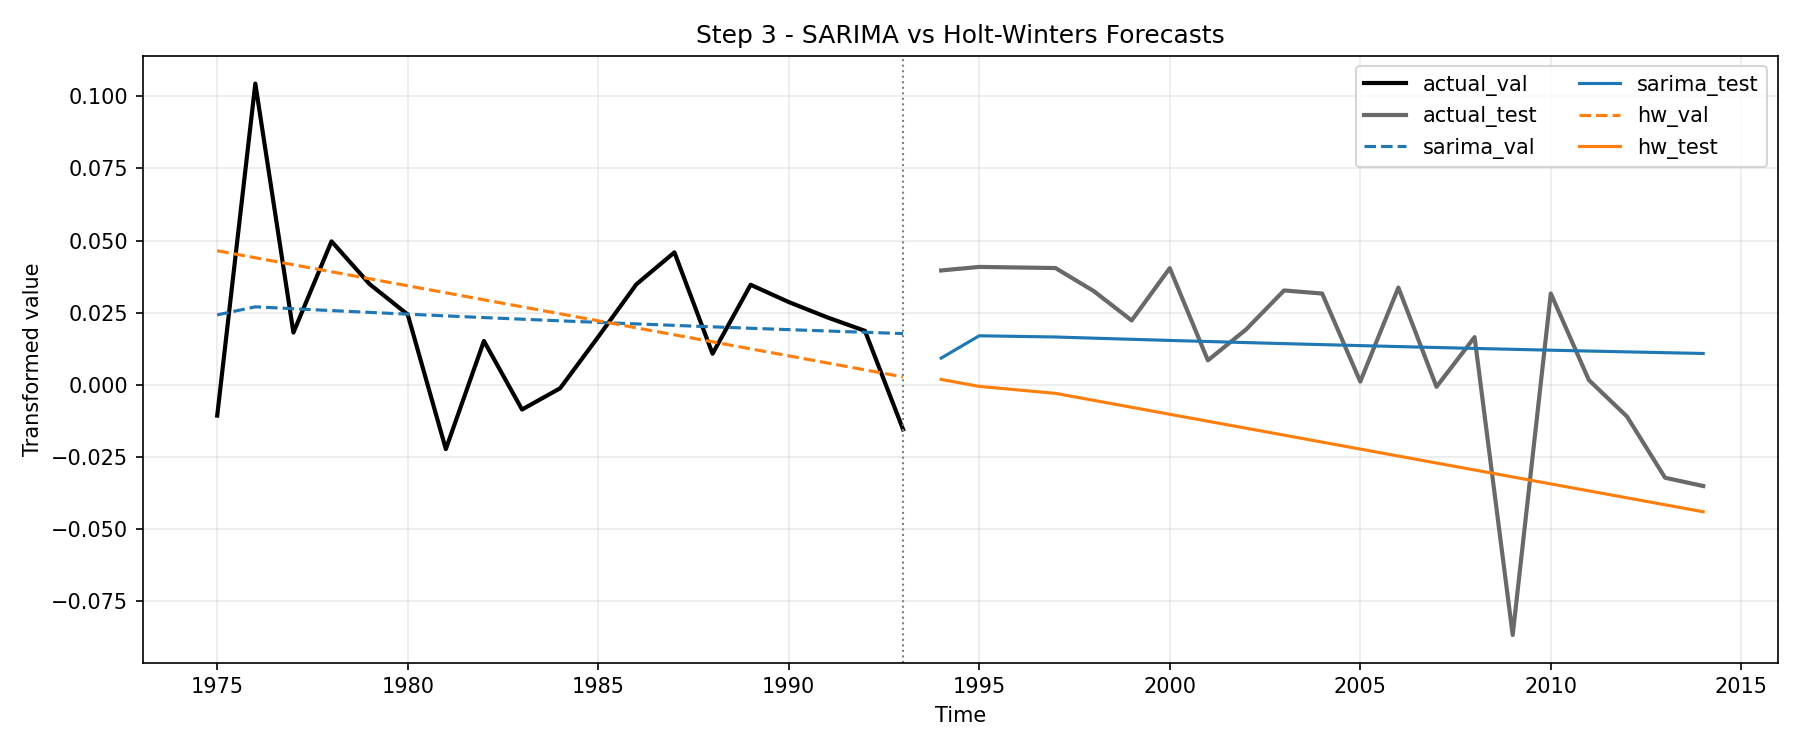

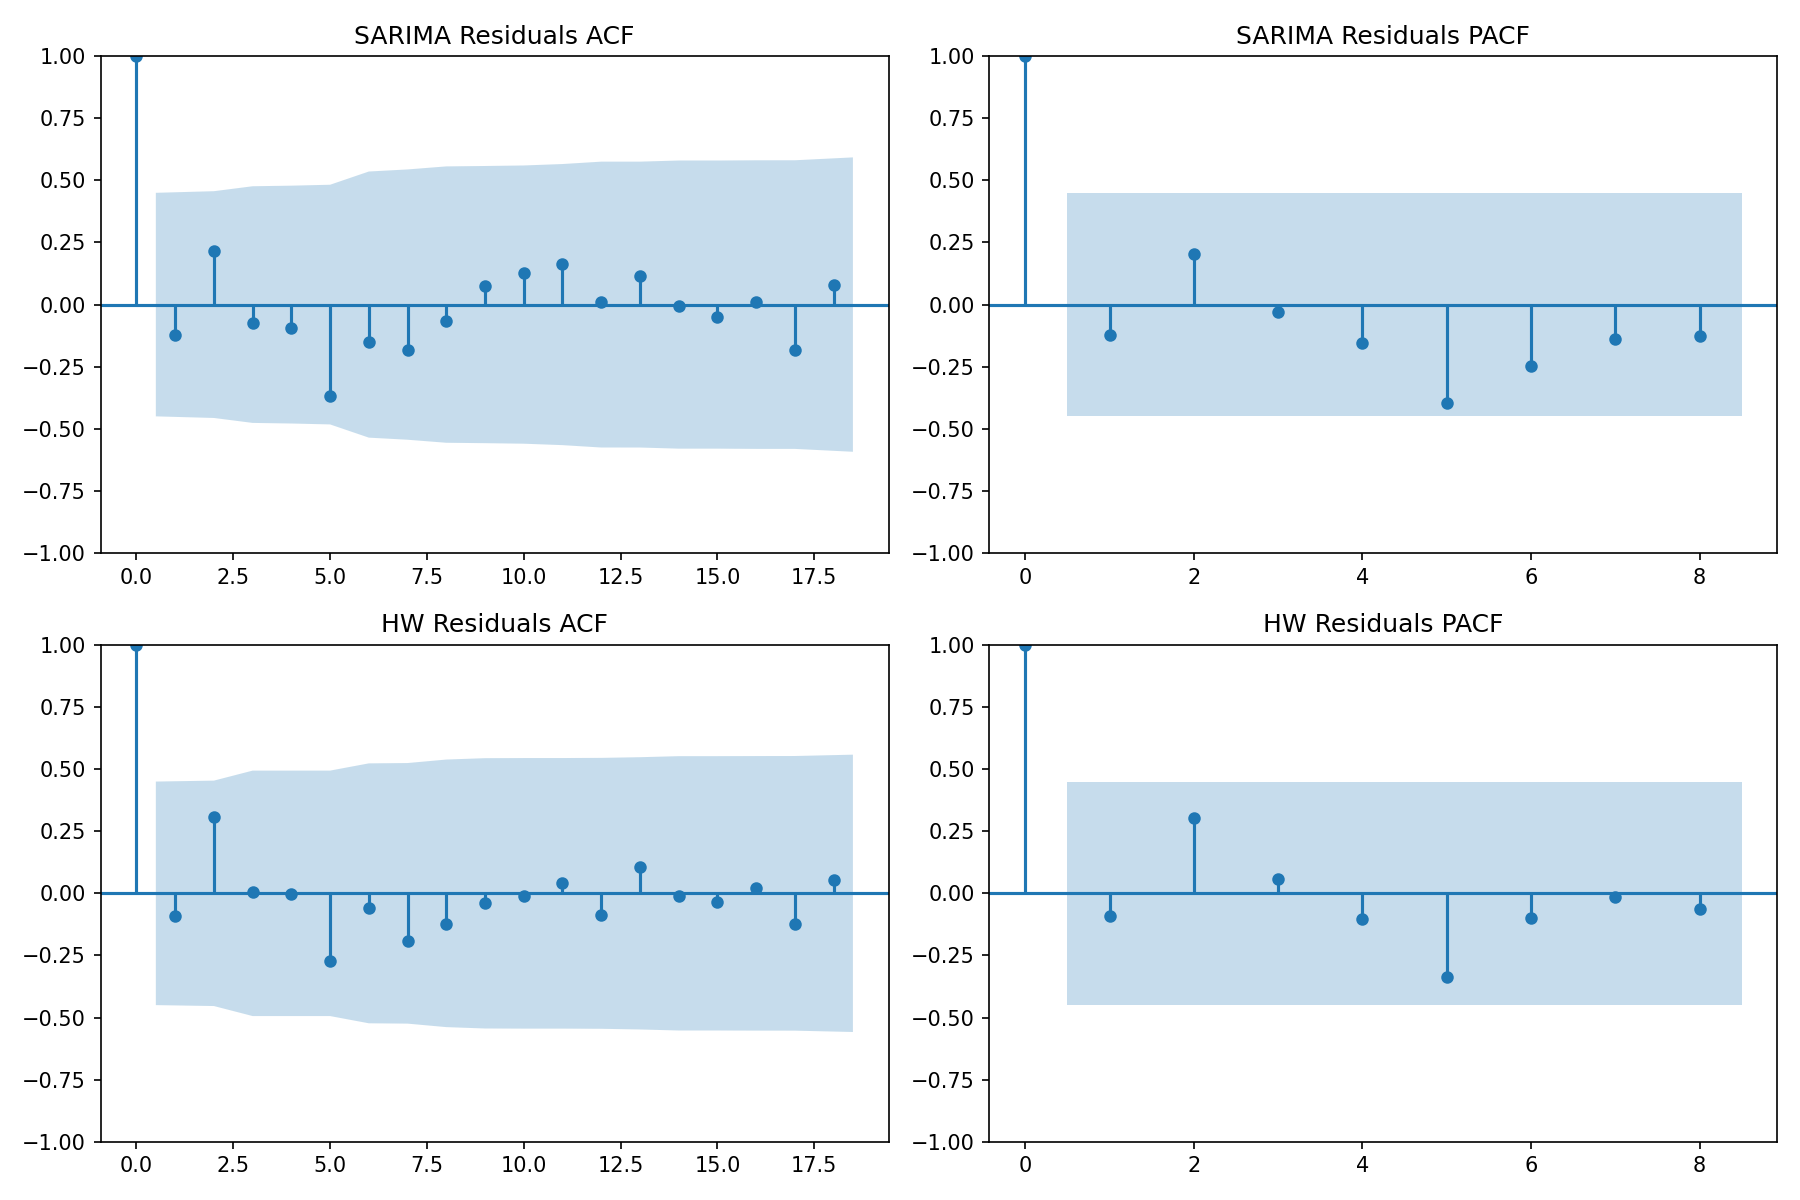

In [130]:
display(stat_summary_df.sort_values("rmse_test"))
display(stat_residual_diag_df)

display(Image(filename=str(stat_plots_dir / "tavola_1_14_stat_forecast_comparison_v1.png")))
display(Image(filename=str(stat_plots_dir / "tavola_1_14_stat_residuals_diagnostics_v1.png")))

### 3.4 Conclusione

Il modello statistico finale viene scelto in base alla **generalizzazione su test** (RMSE principale, MAE come supporto).
L'altro modello resta benchmark ufficiale per il confronto con i rami ML e Neural.

In [131]:
winner_row = stat_summary_df.sort_values(["rmse_test", "mae_test"], ascending=[True, True]).iloc[0]
winner_name = winner_row["model"]

print(f"Winner Step 3: {winner_name}")
print(f"Best params: {winner_row['best_params']}")
print(f"Test RMSE: {winner_row['rmse_test']:.6f}")
print(f"Test MAE: {winner_row['mae_test']:.6f}")
print(f"Test MAPE: {winner_row['mape_test']:.4f}%")

display(stat_winner_params.to_frame("value"))

Winner Step 3: sarima
Best params: {'order': (1, 0, 2), 'seasonal_order': (0, 0, 0, 0)}
Test RMSE: 0.031036
Test MAE: 0.023201
Test MAPE: 253.5831%


,value
model,sarima
best_params,"{'order': (1, 0, 2), 'seasonal_order': (0, 0, ..."
rmse_val,0.02719
mae_val,0.019989
mape_val,194.961412
mbe_val,0.001036
abs_mbe_val,0.001036
rmse_val_orig,6301.982527
mae_val_orig,5327.089365
mape_val_orig,2.909305


### 3.5 Predizioni in scala originale

La logica di inversione (log1p + diff1 -> scala originale) è ora parte del modulo statistico (`sarima_hw.py`) ed è eseguita durante la pipeline in `main.py`.

Qui visualizziamo direttamente il grafico salvato negli artifact di Step 3, così la sezione notebook resta coerente con la logica applicativa.

Original-scale plot: c:\Users\giann\Documents\GitHub\FinalProject\Results\plots\forecasting\tavola_1_14_stat_forecast_original_scale_v1.png


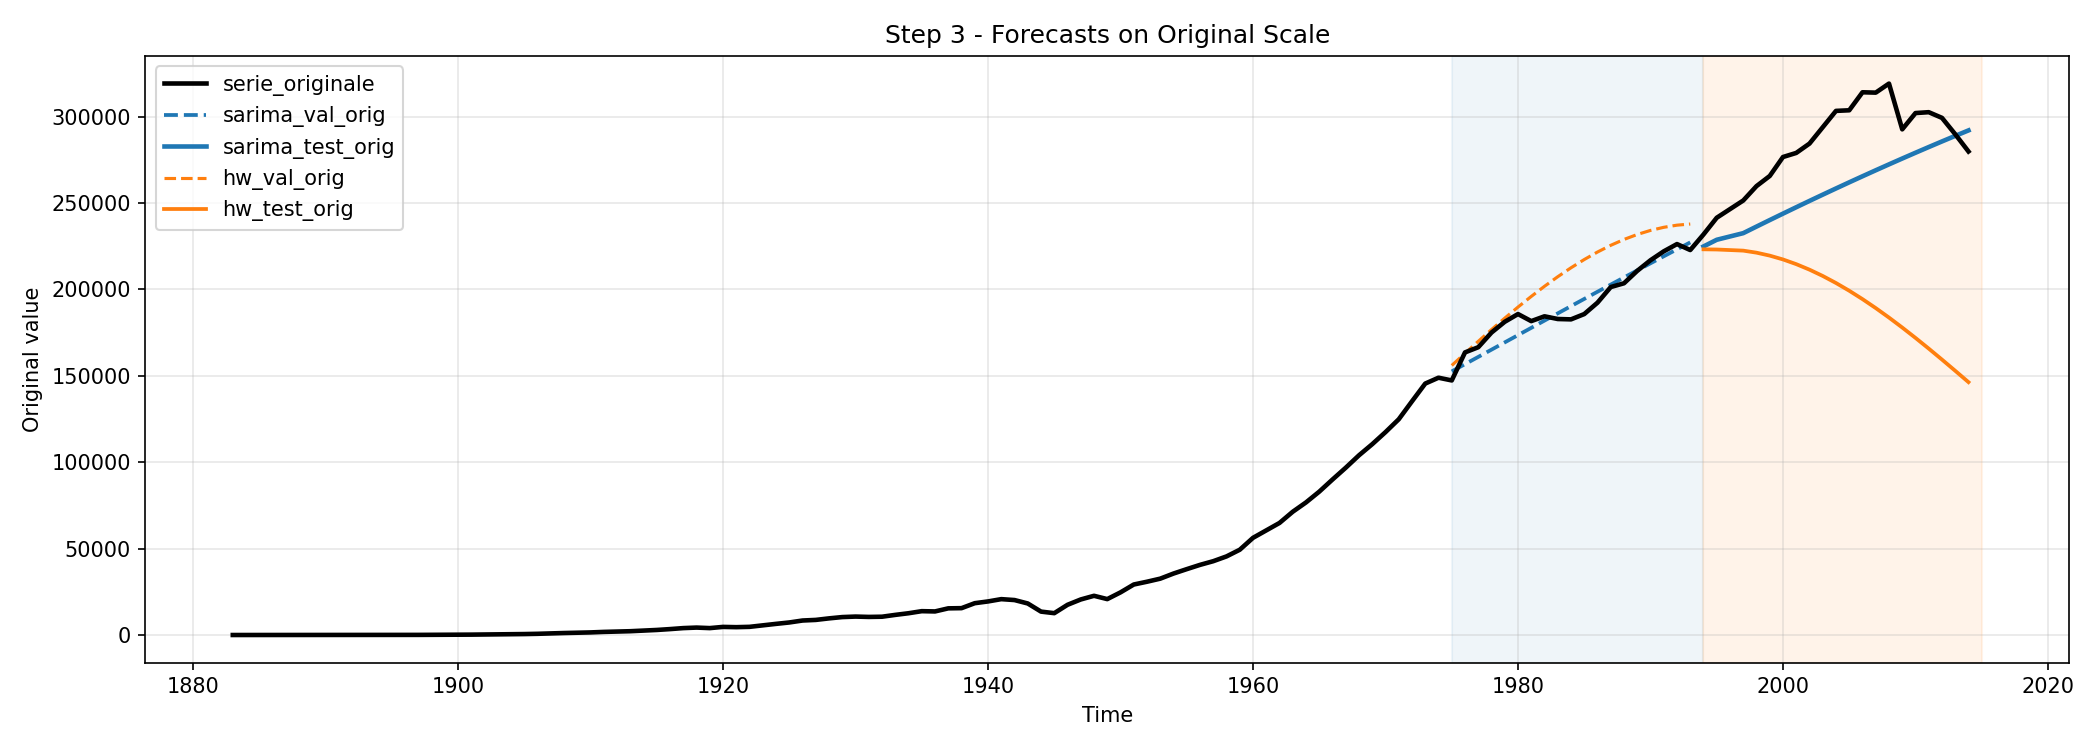

In [132]:
from pathlib import Path
from IPython.display import Image, display

orig_plot_path = stat_plots_dir / "tavola_1_14_stat_forecast_original_scale_v1.png"

print(f"Original-scale plot: {orig_plot_path}")
if Path(orig_plot_path).exists():
    display(Image(filename=str(orig_plot_path)))
else:
    print("Plot non trovato. Esegui main.py per rigenerare gli artifact di Step 3.")